In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

In [9]:
df = pd.read_csv("heart.csv")

In [10]:
df.head()



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(723)

In [5]:

df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [11]:

df.shape

(1025, 14)

In [12]:
df = df.drop_duplicates()


In [13]:
df.shape

(302, 14)

In [14]:
df['target'].value_counts()

target
1    164
0    138
Name: count, dtype: int64

In [16]:
df.fillna(df.mean(), inplace=True)

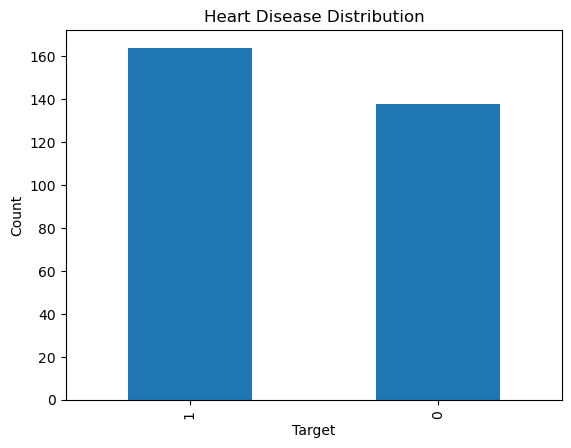

In [17]:
import matplotlib.pyplot as plt

df['target'].value_counts().plot(kind='bar')

plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

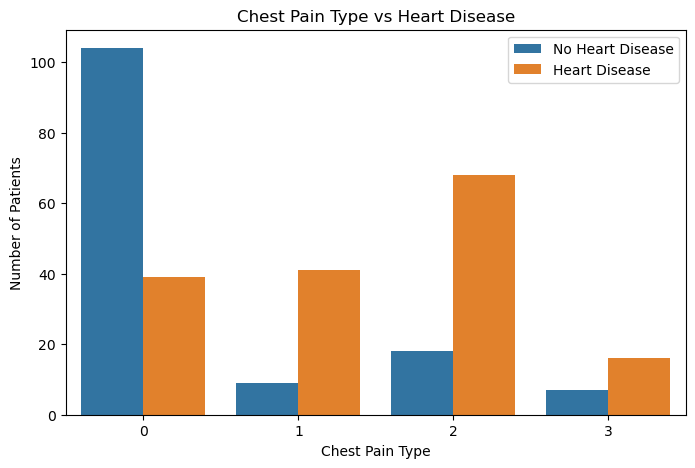

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    x='cp',
    hue='target',
    data=df
)

plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")

plt.legend(
    labels=["No Heart Disease", "Heart Disease"]
)

plt.show()

In [24]:
X = df.drop("target", axis=1)

In [25]:
y = df["target"]


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [28]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [29]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [30]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [31]:
print("Accuracy:", accuracy_score(y_test, lr_pred))

print("Precision:", precision_score(y_test, lr_pred))

print("Recall:", recall_score(y_test, lr_pred))

print("F1 Score:", f1_score(y_test, lr_pred))

Accuracy: 0.7704918032786885
Precision: 0.7027027027027027
Recall: 0.896551724137931
F1 Score: 0.7878787878787878


In [33]:
print(confusion_matrix(y_test,lr_pred))


[[21 11]
 [ 3 26]]


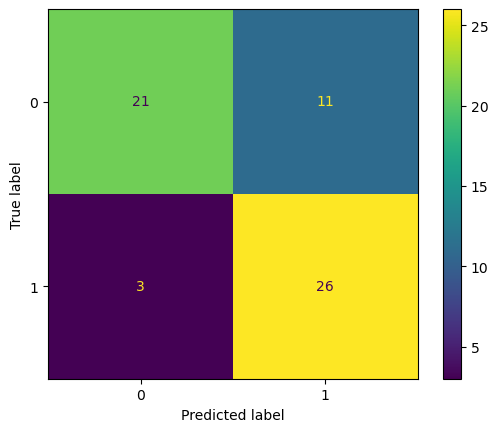

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test)
plt.show()

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [43]:
models = {

    "Logistic Regression": LogisticRegression(),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier()

}

In [44]:
results = []


for name, model in models.items():

    # Training
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)


    # Evaluation
    results.append({

        "Model": name,

        "Accuracy": accuracy_score(y_test, y_pred),

        "Precision": precision_score(y_test, y_pred),

        "Recall": recall_score(y_test, y_pred),

        "F1 Score": f1_score(y_test, y_pred)

    })

In [45]:
import pandas as pd

comparison_df = pd.DataFrame(results)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.770492,0.702703,0.896552,0.787879
1,Decision Tree,0.737705,0.760000,0.655172,0.703704
2,Random Forest,0.852459,0.812500,0.896552,0.852459


In [46]:
comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.852459,0.812500,0.896552,0.852459
0,Logistic Regression,0.770492,0.702703,0.896552,0.787879
1,Decision Tree,0.737705,0.760000,0.655172,0.703704


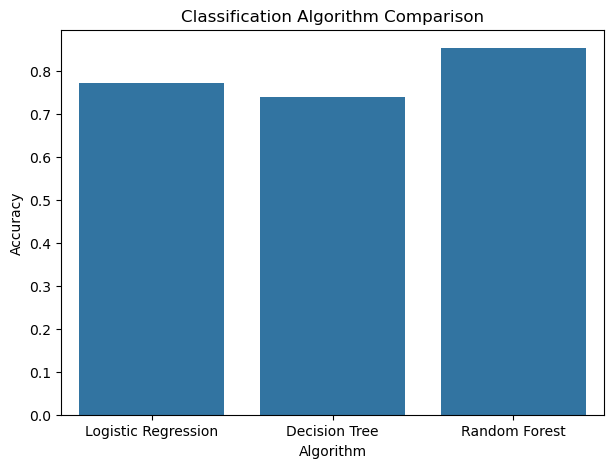

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(7,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=comparison_df
)

plt.title("Classification Algorithm Comparison")

plt.xlabel("Algorithm")

plt.ylabel("Accuracy")

plt.show()

In [48]:
best_model = comparison_df.loc[
    comparison_df['Accuracy'].idxmax()
]

print(best_model)

Model        Random Forest
Accuracy          0.852459
Precision           0.8125
Recall            0.896552
F1 Score          0.852459
Name: 2, dtype: object
